In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [7]:
train_df=pd.read_excel('/kaggle/input/datasets/tanishkagolya/flight-price-prediction-train/Data_Train flight prediction price.xlsx')
train_df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [8]:
test_df=pd.read_excel('/kaggle/input/datasets/tanishkagolya/flight-price-prediction-testing/Test_set flight price prediction.xlsx')
test_df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info
0,Jet Airways,6/06/2019,Delhi,Cochin,DEL → BOM → COK,17:30,04:25 07 Jun,10h 55m,1 stop,No info
1,IndiGo,12/05/2019,Kolkata,Banglore,CCU → MAA → BLR,06:20,10:20,4h,1 stop,No info
2,Jet Airways,21/05/2019,Delhi,Cochin,DEL → BOM → COK,19:15,19:00 22 May,23h 45m,1 stop,In-flight meal not included
3,Multiple carriers,21/05/2019,Delhi,Cochin,DEL → BOM → COK,08:00,21:00,13h,1 stop,No info
4,Air Asia,24/06/2019,Banglore,Delhi,BLR → DEL,23:55,02:45 25 Jun,2h 50m,non-stop,No info


.xlsx (Excel file)

 So correct function is:

pd.read_excel()

In [9]:
final_df=train_df.merge(test_df)
final_df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,Jet Airways,18/05/2019,Delhi,Cochin,DEL → AMD → BOM → COK,19:10,19:00 19 May,23h 50m,2 stops,No info,15129
1,Air India,27/06/2019,Delhi,Cochin,DEL → GOI → BOM → COK,22:00,19:15 28 Jun,21h 15m,2 stops,No info,10441
2,Jet Airways,21/03/2019,Delhi,Cochin,DEL → BDQ → BOM → COK,18:25,18:50 22 Mar,24h 25m,2 stops,In-flight meal not included,9270
3,IndiGo,03/03/2019,Banglore,New Delhi,BLR → DEL,18:55,21:45,2h 50m,non-stop,No info,8855
4,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,00:40,03:25,2h 45m,non-stop,No info,4777


In [10]:
final_df.shape

(273, 11)

In [11]:
final_df.tail(5)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
268,Multiple carriers,6/06/2019,Delhi,Cochin,DEL → BOM → COK,10:00,21:00,11h,1 stop,No info,7933
269,Air India,24/03/2019,Banglore,New Delhi,BLR → DEL,06:10,08:55,2h 45m,non-stop,No info,3758
270,Air India,9/05/2019,Kolkata,Banglore,CCU → BOM → GOI → BLR,16:50,05:35 10 May,12h 45m,2 stops,No info,11432
271,Air India,1/06/2019,Delhi,Cochin,DEL → AMD → BOM → COK,16:40,19:15 02 Jun,26h 35m,2 stops,No info,9863
272,Air India,24/03/2019,Kolkata,Banglore,CCU → BOM → GOI → BLR,09:25,05:35 25 Mar,20h 10m,2 stops,No info,12352


In [12]:
final_df.describe()

,Price
count,273.000000
mean,11139.970696
std,3738.853008
min,3383.000000
25%,8236.000000
50%,11542.000000
75%,13587.000000
max,31783.000000


In [13]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 273 entries, 0 to 272
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          273 non-null    object
 1   Date_of_Journey  273 non-null    object
 2   Source           273 non-null    object
 3   Destination      273 non-null    object
 4   Route            273 non-null    object
 5   Dep_Time         273 non-null    object
 6   Arrival_Time     273 non-null    object
 7   Duration         273 non-null    object
 8   Total_Stops      273 non-null    object
 9   Additional_Info  273 non-null    object
 10  Price            273 non-null    int64 
dtypes: int64(1), object(10)
memory usage: 23.6+ KB


Date_of_Journey

Currently:

object

But actually?
It is DATE.

So here feature engineering required.

In [14]:
final_df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [15]:
final_df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [16]:
final_df['Airline'].value_counts()
final_df['Source'].value_counts()
final_df['Destination'].value_counts()
final_df['Total_Stops'].value_counts()

Total_Stops
2 stops     174
1 stop       50
non-stop     48
3 stops       1
Name: count, dtype: int64

In [17]:
final_df['Date_of_Journey'].str.split('/').str[0]

0      18
1      27
2      21
3      03
4      24
       ..
268     6
269    24
270     9
271     1
272    24
Name: Date_of_Journey, Length: 273, dtype: object

.str.split('/')
"24/03/2019" → ["24", "03", "2019"]

So whole column becomes list-like structure.
This line is basically trying to take a date written like a normal text (for example `"24/03/2019"`) and break it into parts using the `/` symbol. So when you do `str.split('/')`, pandas splits each date into a small list like `["24", "03", "2019"]`, where 24 is the day, 03 is the month, and 2019 is the year. After that, `.str[0]` means you are picking the first item from each list, so you end up extracting only the day part from every date. For example, `"24/03/2019"` becomes `["24","03","2019"]`, and then `.str[0]` gives `"24"`. So overall, this line is used to pull out the day from a date string, but it works only when the column is still stored as text (not converted into real datetime format).



In [18]:
##Fetaure Engineering Process
final_df['Date']=final_df['Date_of_Journey'].str.split('/').str[0]
final_df['Month']=final_df['Date_of_Journey'].str.split('/').str[1]
final_df['Year']=final_df['Date_of_Journey'].str.split('/').str[2]

In [19]:
final_df.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year
0,Jet Airways,18/05/2019,Delhi,Cochin,DEL → AMD → BOM → COK,19:10,19:00 19 May,23h 50m,2 stops,No info,15129,18,05,2019
1,Air India,27/06/2019,Delhi,Cochin,DEL → GOI → BOM → COK,22:00,19:15 28 Jun,21h 15m,2 stops,No info,10441,27,06,2019


In [20]:
final_df["Date"]=final_df['Date_of_Journey'].apply(lambda x:x.split("/")[0])
final_df["Month"]=final_df['Date_of_Journey'].apply(lambda x:x.split("/")[1])
final_df["Year"]=final_df['Date_of_Journey'].apply(lambda x:x.split("/")[2])

apply(lambda x: ...)
 This means:

“Go row by row and apply this function on each value”

So x becomes each date string one by one.

 x.split("/")

Example:

"24/03/2019".split("/")
→ ["24", "03", "2019"]

 Now indexing happens
Index	Value
[0]	"24" → Day
[1]	"03" → Month
[2]	"2019" → Year
 Final Output

create 3 new columns:

Date   → 24
Month  → 03
Year   → 2019
(simple explanation)

This code is basically saying:

“Take each date written as text, cut it into 3 pieces (day, month, year), and store them in separate columns so machine learning model can understand it better.”

 Important note (VERY IMPORTANT)

This works ONLY when:

Date_of_Journey = string type (object)

If it becomes datetime, this will FAIL 

 Better industry way 

Instead of manual splitting, do:

df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'])

df['Date'] = df['Date_of_Journey'].dt.day
df['Month'] = df['Date_of_Journey'].dt.month
df['Year'] = df['Date_of_Journey'].dt.year

cleaner
faster
ML standard
error-free



In [21]:
final_df['Date']=final_df['Date'].astype(int)
final_df['Month']=final_df['Month'].astype(int)
final_df['Year']=final_df['Year'].astype(int)

In [22]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 273 entries, 0 to 272
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          273 non-null    object
 1   Date_of_Journey  273 non-null    object
 2   Source           273 non-null    object
 3   Destination      273 non-null    object
 4   Route            273 non-null    object
 5   Dep_Time         273 non-null    object
 6   Arrival_Time     273 non-null    object
 7   Duration         273 non-null    object
 8   Total_Stops      273 non-null    object
 9   Additional_Info  273 non-null    object
 10  Price            273 non-null    int64 
 11  Date             273 non-null    int64 
 12  Month            273 non-null    int64 
 13  Year             273 non-null    int64 
dtypes: int64(4), object(10)
memory usage: 30.0+ KB


In [23]:
final_df.drop('Date_of_Journey',axis=1,inplace=True)

In [24]:
final_df.shape

(273, 13)

In [25]:
final_df.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year
0,Jet Airways,Delhi,Cochin,DEL → AMD → BOM → COK,19:10,19:00 19 May,23h 50m,2 stops,No info,15129,18,5,2019
1,Air India,Delhi,Cochin,DEL → GOI → BOM → COK,22:00,19:15 28 Jun,21h 15m,2 stops,No info,10441,27,6,2019
2,Jet Airways,Delhi,Cochin,DEL → BDQ → BOM → COK,18:25,18:50 22 Mar,24h 25m,2 stops,In-flight meal not included,9270,21,3,2019
3,IndiGo,Banglore,New Delhi,BLR → DEL,18:55,21:45,2h 50m,non-stop,No info,8855,3,3,2019
4,IndiGo,Banglore,New Delhi,BLR → DEL,00:40,03:25,2h 45m,non-stop,No info,4777,24,3,2019


In [26]:
final_df['Arrival_Time']

0      19:00 19 May
1      19:15 28 Jun
2      18:50 22 Mar
3             21:45
4             03:25
           ...     
268           21:00
269           08:55
270    05:35 10 May
271    19:15 02 Jun
272    05:35 25 Mar
Name: Arrival_Time, Length: 273, dtype: object

In [27]:
final_df['Arrival_Time'].str.split(' ')

0      [19:00, 19, May]
1      [19:15, 28, Jun]
2      [18:50, 22, Mar]
3               [21:45]
4               [03:25]
             ...       
268             [21:00]
269             [08:55]
270    [05:35, 10, May]
271    [19:15, 02, Jun]
272    [05:35, 25, Mar]
Name: Arrival_Time, Length: 273, dtype: object

In [28]:
final_df['Arrival_Time'].str.split(' ').str[0]

0      19:00
1      19:15
2      18:50
3      21:45
4      03:25
       ...  
268    21:00
269    08:55
270    05:35
271    19:15
272    05:35
Name: Arrival_Time, Length: 273, dtype: object

In [29]:
final_df['Arrival_Time']=final_df['Arrival_Time'].apply(lambda x : x.split(' ')[0])

Remove date part from arrival time and keep only clock time

In [30]:
final_df['Arrival_hour']=final_df['Arrival_Time'].str.split(':').str[0]
final_df['Arrival_min']=final_df['Arrival_Time'].str.split(':').str[1]

In [31]:
final_df.head(2)

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min
0,Jet Airways,Delhi,Cochin,DEL → AMD → BOM → COK,19:10,19:00,23h 50m,2 stops,No info,15129,18,5,2019,19,00
1,Air India,Delhi,Cochin,DEL → GOI → BOM → COK,22:00,19:15,21h 15m,2 stops,No info,10441,27,6,2019,19,15


In [32]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 273 entries, 0 to 272
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          273 non-null    object
 1   Source           273 non-null    object
 2   Destination      273 non-null    object
 3   Route            273 non-null    object
 4   Dep_Time         273 non-null    object
 5   Arrival_Time     273 non-null    object
 6   Duration         273 non-null    object
 7   Total_Stops      273 non-null    object
 8   Additional_Info  273 non-null    object
 9   Price            273 non-null    int64 
 10  Date             273 non-null    int64 
 11  Month            273 non-null    int64 
 12  Year             273 non-null    int64 
 13  Arrival_hour     273 non-null    object
 14  Arrival_min      273 non-null    object
dtypes: int64(4), object(11)
memory usage: 32.1+ KB


Remove date part from arrival time and keep only clock time.

In [33]:
final_df.drop('Arrival_Time',axis=1,inplace=True)

In [34]:
final_df.head()

,Airline,Source,Destination,Route,Dep_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min
0,Jet Airways,Delhi,Cochin,DEL → AMD → BOM → COK,19:10,23h 50m,2 stops,No info,15129,18,5,2019,19,00
1,Air India,Delhi,Cochin,DEL → GOI → BOM → COK,22:00,21h 15m,2 stops,No info,10441,27,6,2019,19,15
2,Jet Airways,Delhi,Cochin,DEL → BDQ → BOM → COK,18:25,24h 25m,2 stops,In-flight meal not included,9270,21,3,2019,18,50
3,IndiGo,Banglore,New Delhi,BLR → DEL,18:55,2h 50m,non-stop,No info,8855,3,3,2019,21,45
4,IndiGo,Banglore,New Delhi,BLR → DEL,00:40,2h 45m,non-stop,No info,4777,24,3,2019,03,25


In [35]:

final_df['Dept_hour']=final_df['Dep_Time'].str.split(':').str[0]
final_df['Dept_min']=final_df['Dep_Time'].str.split(':').str[1]
final_df['Dept_hour']=final_df['Dept_hour'].astype(int)
final_df['Dept_min']=final_df['Dept_min'].astype(int)
final_df.drop('Dep_Time',axis=1,inplace=True)

In [36]:
final_df.head(1)

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min,Dept_hour,Dept_min
0,Jet Airways,Delhi,Cochin,DEL → AMD → BOM → COK,23h 50m,2 stops,No info,15129,18,5,2019,19,00,19,10


In [37]:
final_df.shape

(273, 15)

In [38]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 273 entries, 0 to 272
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          273 non-null    object
 1   Source           273 non-null    object
 2   Destination      273 non-null    object
 3   Route            273 non-null    object
 4   Duration         273 non-null    object
 5   Total_Stops      273 non-null    object
 6   Additional_Info  273 non-null    object
 7   Price            273 non-null    int64 
 8   Date             273 non-null    int64 
 9   Month            273 non-null    int64 
 10  Year             273 non-null    int64 
 11  Arrival_hour     273 non-null    object
 12  Arrival_min      273 non-null    object
 13  Dept_hour        273 non-null    int64 
 14  Dept_min         273 non-null    int64 
dtypes: int64(6), object(9)
memory usage: 32.1+ KB


In [39]:
final_df.head(2)

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min,Dept_hour,Dept_min
0,Jet Airways,Delhi,Cochin,DEL → AMD → BOM → COK,23h 50m,2 stops,No info,15129,18,5,2019,19,00,19,10
1,Air India,Delhi,Cochin,DEL → GOI → BOM → COK,21h 15m,2 stops,No info,10441,27,6,2019,19,15,22,0


In [40]:
final_df['Total_Stops'].unique()

array(['2 stops', 'non-stop', '1 stop', '3 stops'], dtype=object)

In [41]:
final_df['Total_Stops']=final_df['Total_Stops'].map({'non-stop':0,'1 stop':1,'2 stops':2,'3 stops':3,'4 stops':4,'nan':1})

In [42]:
final_df[final_df['Total_Stops'].isnull()]

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min,Dept_hour,Dept_min


In [43]:
final_df.head(2)

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min,Dept_hour,Dept_min
0,Jet Airways,Delhi,Cochin,DEL → AMD → BOM → COK,23h 50m,2,No info,15129,18,5,2019,19,00,19,10
1,Air India,Delhi,Cochin,DEL → GOI → BOM → COK,21h 15m,2,No info,10441,27,6,2019,19,15,22,0


In [44]:
final_df.head(1)

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min,Dept_hour,Dept_min
0,Jet Airways,Delhi,Cochin,DEL → AMD → BOM → COK,23h 50m,2,No info,15129,18,5,2019,19,00,19,10


In [45]:
final_df.drop('Route',axis=1,inplace=True)

In [46]:
final_df.head(1)

,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min,Dept_hour,Dept_min
0,Jet Airways,Delhi,Cochin,23h 50m,2,No info,15129,18,5,2019,19,00,19,10


In [47]:
final_df['Additional_Info'].unique()

array(['No info', 'In-flight meal not included'], dtype=object)

In [48]:
final_df['Duration']=final_df['Duration'].str.split(' ').str[0].str.split('h').str[0]

In [49]:
final_df.head(1)

,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min,Dept_hour,Dept_min
0,Jet Airways,Delhi,Cochin,23,2,No info,15129,18,5,2019,19,00,19,10


In [50]:
final_df[final_df['Duration'] == '5m']

,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min,Dept_hour,Dept_min


In [51]:
final_df.columns

Index(['Airline', 'Source', 'Destination', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price', 'Date', 'Month', 'Year', 'Arrival_hour',
       'Arrival_min', 'Dept_hour', 'Dept_min'],
      dtype='object')

In [52]:

final_df.index

RangeIndex(start=0, stop=273, step=1)

In [53]:
final_df.drop('Duration',axis=1,inplace=True)

In [54]:
final_df.head(2)

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min,Dept_hour,Dept_min
0,Jet Airways,Delhi,Cochin,2,No info,15129,18,5,2019,19,00,19,10
1,Air India,Delhi,Cochin,2,No info,10441,27,6,2019,19,15,22,0


In [55]:
final_df['Airline'].unique()

array(['Jet Airways', 'Air India', 'IndiGo', 'Multiple carriers', 'GoAir',
       'Air Asia', 'SpiceJet', 'Vistara'], dtype=object)

In [56]:
final_df.tail(5)

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min,Dept_hour,Dept_min
268,Multiple carriers,Delhi,Cochin,1,No info,7933,6,6,2019,21,00,10,0
269,Air India,Banglore,New Delhi,0,No info,3758,24,3,2019,08,55,6,10
270,Air India,Kolkata,Banglore,2,No info,11432,9,5,2019,05,35,16,50
271,Air India,Delhi,Cochin,2,No info,9863,1,6,2019,19,15,16,40
272,Air India,Kolkata,Banglore,2,No info,12352,24,3,2019,05,35,9,25


In [57]:
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()


In [58]:
final_df['Airline']=labelencoder.fit_transform(final_df['Airline'])
final_df['Source']=labelencoder.fit_transform(final_df['Source'])
final_df['Destination']=labelencoder.fit_transform(final_df['Destination'])
final_df['Additional_Info']=labelencoder.fit_transform(final_df['Additional_Info'])

In [59]:
final_df.shape

(273, 13)

In [60]:
final_df.head(2)

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min,Dept_hour,Dept_min
0,4,1,1,2,1,15129,18,5,2019,19,00,19,10
1,1,1,1,2,1,10441,27,6,2019,19,15,22,0


In [61]:
final_df[['Airline']]

,Airline
0,4
1,1
2,4
3,3
4,3
...,...
268,5
269,1
270,1
271,1


In [62]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()

In [63]:
ohe.fit_transform(np.array(final_df['Airline']).reshape(-1,1))

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 273 stored elements and shape (273, 8)>

In [64]:
final_df.head()

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min,Dept_hour,Dept_min
0,4,1,1,2,1,15129,18,5,2019,19,00,19,10
1,1,1,1,2,1,10441,27,6,2019,19,15,22,0
2,4,1,1,2,0,9270,21,3,2019,18,50,18,25
3,3,0,2,0,1,8855,3,3,2019,21,45,18,55
4,3,0,2,0,1,4777,24,3,2019,03,25,0,40


In [65]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 273 entries, 0 to 272
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          273 non-null    int64 
 1   Source           273 non-null    int64 
 2   Destination      273 non-null    int64 
 3   Total_Stops      273 non-null    int64 
 4   Additional_Info  273 non-null    int64 
 5   Price            273 non-null    int64 
 6   Date             273 non-null    int64 
 7   Month            273 non-null    int64 
 8   Year             273 non-null    int64 
 9   Arrival_hour     273 non-null    object
 10  Arrival_min      273 non-null    object
 11  Dept_hour        273 non-null    int64 
 12  Dept_min         273 non-null    int64 
dtypes: int64(11), object(2)
memory usage: 27.9+ KB


In [66]:
pd.get_dummies(final_df,columns=["Airline", "Source", "Destination"] ,drop_first = True,dtype=int)

,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min,Dept_hour,Dept_min,...,Airline_2,Airline_3,Airline_4,Airline_5,Airline_6,Airline_7,Source_1,Source_2,Destination_1,Destination_2
0,2,1,15129,18,5,2019,19,00,19,10,...,0,0,1,0,0,0,1,0,1,0
1,2,1,10441,27,6,2019,19,15,22,0,...,0,0,0,0,0,0,1,0,1,0
2,2,0,9270,21,3,2019,18,50,18,25,...,0,0,1,0,0,0,1,0,1,0
3,0,1,8855,3,3,2019,21,45,18,55,...,0,1,0,0,0,0,0,0,0,1
4,0,1,4777,24,3,2019,03,25,0,40,...,0,1,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268,1,1,7933,6,6,2019,21,00,10,0,...,0,0,0,1,0,0,1,0,1,0
269,0,1,3758,24,3,2019,08,55,6,10,...,0,0,0,0,0,0,0,0,0,1
270,2,1,11432,9,5,2019,05,35,16,50,...,0,0,0,0,0,0,0,1,0,0
271,2,1,9863,1,6,2019,19,15,16,40,...,0,0,0,0,0,0,1,0,1,0


In [67]:
final_df.head()

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_min,Dept_hour,Dept_min
0,4,1,1,2,1,15129,18,5,2019,19,00,19,10
1,1,1,1,2,1,10441,27,6,2019,19,15,22,0
2,4,1,1,2,0,9270,21,3,2019,18,50,18,25
3,3,0,2,0,1,8855,3,3,2019,21,45,18,55
4,3,0,2,0,1,4777,24,3,2019,03,25,0,40


In [68]:
final_df.shape

(273, 13)

In [69]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 273 entries, 0 to 272
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          273 non-null    int64 
 1   Source           273 non-null    int64 
 2   Destination      273 non-null    int64 
 3   Total_Stops      273 non-null    int64 
 4   Additional_Info  273 non-null    int64 
 5   Price            273 non-null    int64 
 6   Date             273 non-null    int64 
 7   Month            273 non-null    int64 
 8   Year             273 non-null    int64 
 9   Arrival_hour     273 non-null    object
 10  Arrival_min      273 non-null    object
 11  Dept_hour        273 non-null    int64 
 12  Dept_min         273 non-null    int64 
dtypes: int64(11), object(2)
memory usage: 27.9+ KB


In [70]:
#univariate analysis
final_df['Airline'].value_counts()

Airline
4    109
1     76
5     50
3     22
2      6
6      6
0      2
7      2
Name: count, dtype: int64

<Axes: xlabel='Price', ylabel='Count'>

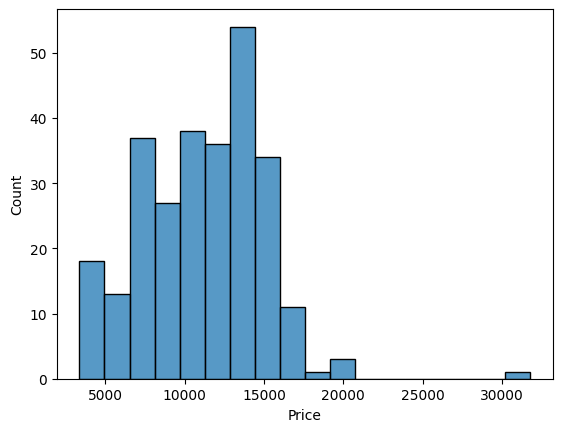

In [71]:
sns.histplot(final_df['Price'])

<Axes: ylabel='Price'>

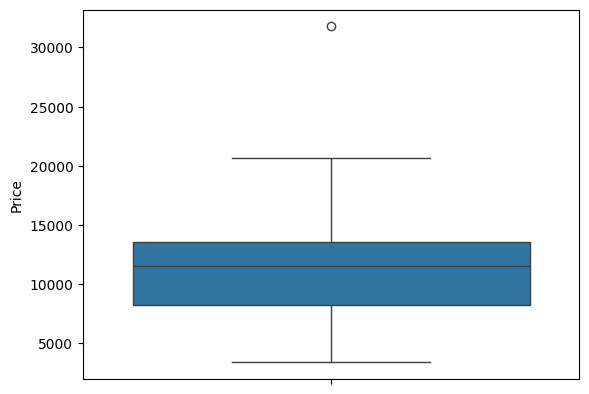

In [72]:
sns.boxplot(final_df['Price'])

<Axes: xlabel='Airline', ylabel='Price'>

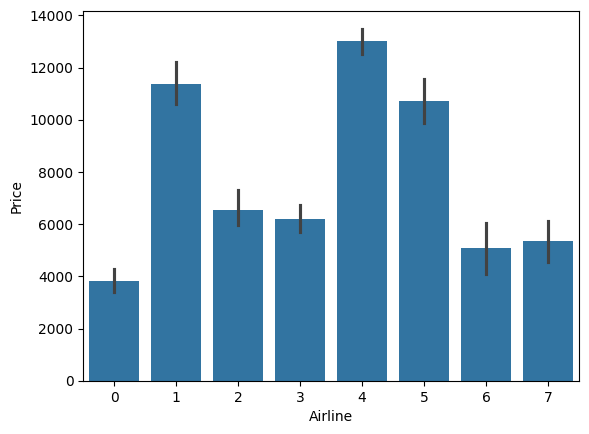

In [73]:
#. Bivariate Analysis
sns.barplot(x='Airline', y='Price', data=final_df)

airline 4 is expensive.. cheap - 0 

<Axes: xlabel='Total_Stops', ylabel='Price'>

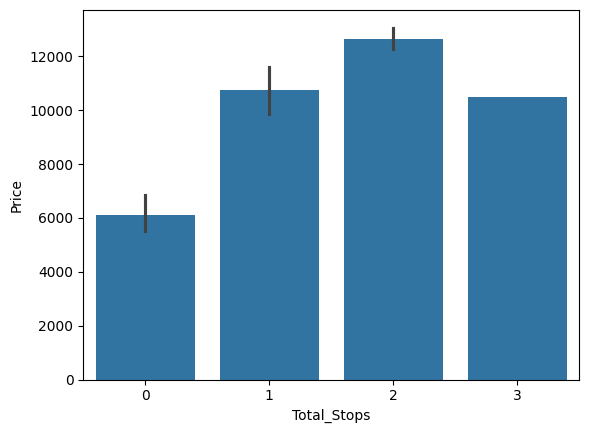

In [74]:
sns.barplot(x='Total_Stops', y='Price', data=final_df)

stop 0 price less.. while stop 2 price is higher.

<Axes: xlabel='Destination', ylabel='Price'>

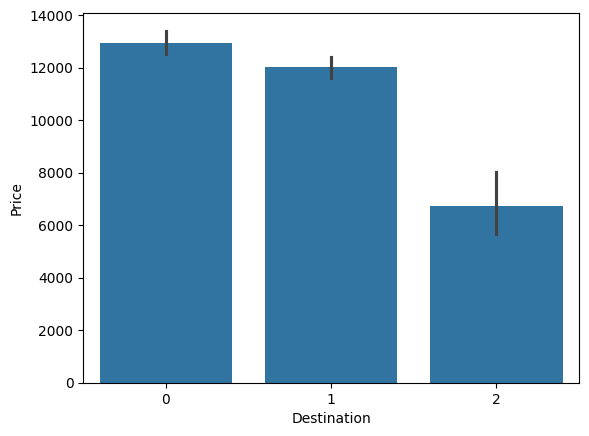

In [75]:
sns.barplot(x='Destination', y='Price', data=final_df)

In [76]:
final_df['Destination'].value_counts()

Destination
1    199
2     50
0     24
Name: count, dtype: int64

In [77]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 273 entries, 0 to 272
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          273 non-null    int64 
 1   Source           273 non-null    int64 
 2   Destination      273 non-null    int64 
 3   Total_Stops      273 non-null    int64 
 4   Additional_Info  273 non-null    int64 
 5   Price            273 non-null    int64 
 6   Date             273 non-null    int64 
 7   Month            273 non-null    int64 
 8   Year             273 non-null    int64 
 9   Arrival_hour     273 non-null    object
 10  Arrival_min      273 non-null    object
 11  Dept_hour        273 non-null    int64 
 12  Dept_min         273 non-null    int64 
dtypes: int64(11), object(2)
memory usage: 27.9+ KB


<Axes: >

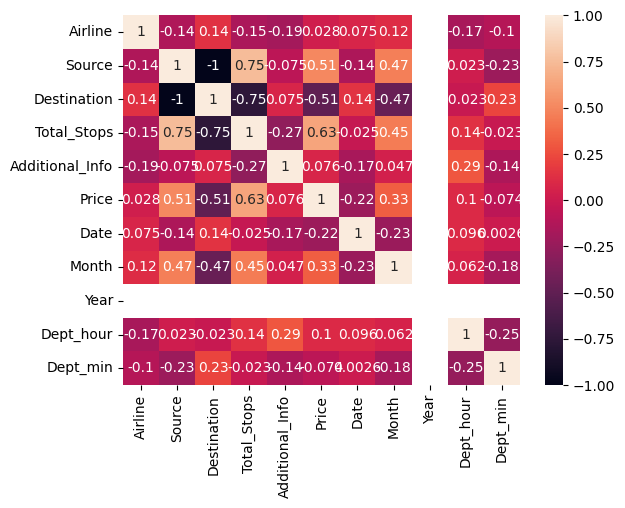

In [78]:
#Correlation Analysis
corr = final_df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)

Correlation Heatmap Analysis

This graph helps understand:

Which features are strongly related to each other?
Which features affect Price?

Correlation values always lie between:

-1  to  +1

Value	Meaning
+1	Perfect positive relation
-1	Perfect negative relation
0	No relation

Positive Correlation (+)

Example:

Stops ↑  → Price ↑

Both move in SAME direction.

 Negative Correlation (-)

Example:

Destination ↑ → Price ↓

One increases, other decreases.

Color	Meaning
Light/white--	strong positive
Dark/black--	strong negative
Middle shades	--weak relation



1. Total_Stops ↔ Price = 0.63

This is VERY IMPORTANT.

0.63 = strong positive correlation

Meaning:

More stops → generally higher ticket price.

This is a GOOD predictive feature for ML model 

 2. Destination ↔ Price = -0.51

Moderately strong negative relation.

Meaning:
Some destinations may generally have lower prices.

 3. Source ↔ Price = 0.51

Moderate positive relation.

Meaning:
Flight source city affects ticket price.

Very logical business insight 

 4. Month ↔ Price = 0.33

Weak-to-moderate positive relation.

Meaning:
Some months have slightly higher prices.

Possible reasons:

holidays
summer travel
vacation season

 5. Date ↔ Price = -0.22

Very weak negative relation.

Meaning:
Day of month doesn’t affect price much.

6. Airline ↔ Price = 0.028

Almost ZERO relation.

Meaning:
In your encoded version, airline feature is not showing linear relation strongly.

BUT IMPORTANT 

This does NOT mean airline is useless.

Because:

encoding style affects correlation
non-linear models still use it well.

but Source ↔ Destination = -1

This is suspicious 

Perfect negative correlation almost NEVER happens naturally.


<Axes: xlabel='Price', ylabel='Count'>

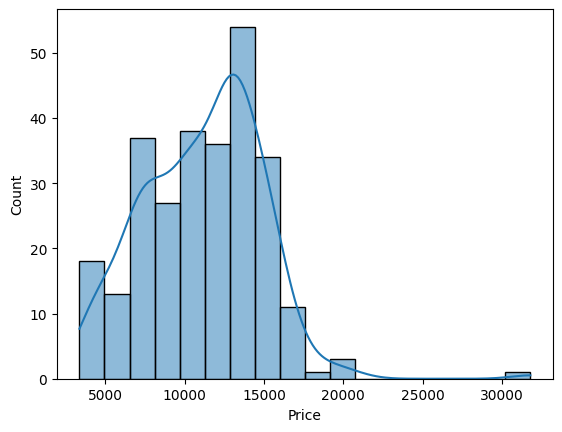

In [79]:
sns.histplot(final_df['Price'], kde=True)

<Axes: ylabel='Price'>

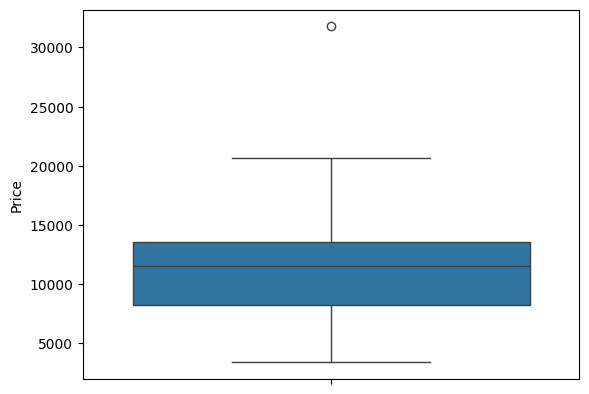

In [80]:
sns.boxplot(final_df['Price'])

In [81]:

sns.boxplot(final_df['Price'])

This helps detect:

spread of data
 median
 outliers
 skewness

1. Middle Line = Median

The line inside box is around:


11000–11500


Meaning:

 Half flights cost below this
 Half flights cost above this

This is your dataset’s middle price.


2. Box = IQR Range

The box roughly spans:

8000 → 13500

This is where MOST flight prices lie.

This is considered:
normal range

3. Whiskers
Lower whisker:

~3500
Upper whisker:
~21000
`

These represent typical lower & upper ranges.



4. OUTLIER DETECTED

their is  one point around:
32000
That isolated dot is an OUTLIER..
it may because of-
* unusually expensive flight
* rare observation

it may be - 
Is this wrong data?
OR
premium/business class flight?

should we remove this outlier directly???

NOT immediately 

Because in flight datasets:

* premium flights ARE possible
* expensive routes ARE realistic

So this may be VALID data.

first Check that row:

final_df[final_df['Price'] > 30000]

See:

* airline
* route
* stops
* duration

Then decide.

| Observation                    | Meaning             |
| ------------------------------ | ------------------- |
| Most prices 8k–13k             | normal range        |
| One high point                 | outlier             |
| Data slightly stretched upward | possible right skew |



SyntaxError: invalid character '–' (U+2013) (1256190093.py, line 15)

In [ ]:
final_df[final_df['Price'] > 30000]

In [ ]:
sns.barplot(x='Total_Stops', y='Price', data=final_df)